In [79]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('Electronic_sales_Sep2023-Sep2024.csv')

In [43]:
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [44]:
#task 1

In [45]:
df['Order Status'].unique()

array(['Cancelled', 'Completed'], dtype=object)

In [46]:
df[df['Order Status'] == 'Completed']['Customer ID'].unique().shape

(9466,)

In [47]:

#nan в price 
df['Total Price'] = df['Total Price'].fillna(0)
df['Add-on Total'] = df['Add-on Total'].fillna(0)
# в payment method просто вставляем самый частый по клиенту
modes = df.groupby('Customer ID').agg({
    'Payment Method' : lambda x : x.value_counts(ascending=False).sort_index(ascending=True).index[0]
    })['Payment Method']
df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].map(modes))
#preffered payment - при равенстве по алфавиту
#остальные случаи учтены по дефолту изходя из составления groupby
df[df['Order Status'] == 'Completed'].groupby(['Customer ID']).agg({
    'Payment Method' : lambda x : x.value_counts(ascending=False).sort_index(ascending=True).index[0], 
    'Total Price' : 'sum',
    'Add-on Total' : 'sum',
    'Customer ID' : 'count'}).rename({
    'Payment Method' : 'preffered_payment',
    'Total Price' : 'total_spent',
    'Add-on Total' : 'addons_spent',
    'Customer ID' : 'orders_count'
}, axis = 1).sort_values(by='orders_count', ascending=False).iloc[:10, :]

,preffered_payment,total_spent,addons_spent,orders_count
Customer ID,,,,
2556,Cash,26098.40,230.66,6
16357,Bank Transfer,27486.01,352.75,6
4192,Credit Card,15244.23,215.33,6
4224,Cash,15691.54,445.60,6
15998,Bank Transfer,19893.30,291.82,5
3043,Cash,13596.15,201.44,5
14422,Bank Transfer,21390.62,316.69,5
17798,Bank Transfer,17848.73,277.10,5
19378,Bank Transfer,10834.79,528.31,5


In [48]:
#task 2

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4

In [50]:
def clean(df):
    #удаляем аномалии тк непонятна реальная стоимость и оплата
    df = df[df['Total Price'] >= 0]
    df = df[df['Add-on Total'] >= 0]
    df = df[df['Unit Price'] >= 0]

    #nan в price 
    df['Total Price'] = df['Total Price'].fillna(0)
    df['Add-on Total'] = df['Add-on Total'].fillna(0)
    # в payment method просто вставляем самый частый по клиенту
    modes = df.groupby('Customer ID').agg({
        'Payment Method' : lambda x : x.value_counts(ascending=False).sort_index(ascending=True).index[0]
        })['Payment Method']
    df['Payment Method'] = df['Payment Method'].fillna(df['Payment Method'].map(modes))
    df['Add-ons Purchased'] = df['Add-ons Purchased'].fillna('unknown')
    
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])   
    return df
    

In [51]:
df = clean(df)


In [52]:
df

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,unknown,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,unknown,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Cancelled,Credit Card,2697.28,674.32,4,2024-07-18,Standard,unknown,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


In [54]:
df.groupby('Shipping Type', as_index=False).agg({'Total Price': 'sum'})

,Shipping Type,Total Price
0,Expedited,12437526.21
1,Express,8685215.62
2,Overnight,8704828.17
3,Same Day,12432024.82
4,Standard,21343073.55


In [76]:
def build_metrics(df):
    
    # доход по методу доставки
    shipping_type_revenue = df.groupby('Shipping Type', as_index=False) \
    .agg({'Total Price': 'sum'}) \
    .rename({'Total Price' : 'shipping_revenue'}, axis=1)
    
    # доход по типу продукта
    product_revenue = df.groupby('Product Type', as_index=False) \
    .agg({'Total Price': 'sum'}) \
    .rename({'Total Price' : 'product_revenue'}, axis=1)
    
    #addons by month
    df['months'] = df['Purchase Date'].dt.to_period('M').dt.to_timestamp()
    addons_months = df.groupby('months', as_index=False) \
    .agg({'Add-on Total' : 'sum'}) \
    .rename({'Add-on Total' : 'addons_revenue'})
    
    #cohort
    df["month"] = df.groupby("Customer ID")["months"].transform("min")

    df["cohort_index"] = (df["months"].dt.year - df["month"].dt.year) * 12 + (
        df["months"].dt.month - df["month"].dt.month
    )

    df_filtered = df[df["cohort_index"].isin([0, 1, 2, 3])]

    buyers_cohorts = df_filtered.pivot_table(
        index="month",
        columns="cohort_index",
        values="Customer ID",
        aggfunc="nunique",
    ).fillna(0)

    buyers_cohorts.index = buyers_cohorts.index.strftime("%Y-%m")    
    
    metrics = {
        'revenue_by_shipping': shipping_type_revenue,
        'revenue_by_product' : product_revenue,
        'addons_by_months' : addons_months,
        'cohort' : buyers_cohorts
    }
    
    return metrics
    

In [82]:
metrics = build_metrics(df)

In [84]:
metrics

{'revenue_by_shipping':   Shipping Type  shipping_revenue
 0     Expedited       12437526.21
 1       Express        8685215.62
 2     Overnight        8704828.17
 3      Same Day       12432024.82
 4      Standard       21343073.55,
 'revenue_by_product':   Product Type  product_revenue
 0   Headphones       4041400.24
 1       Laptop      12296239.97
 2   Smartphone      21516754.69
 3   Smartwatch      14036273.06
 4       Tablet      11712000.41,
 'addons_by_months':        months  Add-on Total
 0  2023-09-01       8012.62
 1  2023-10-01      37837.12
 2  2023-11-01      34888.81
 3  2023-12-01      33509.15
 4  2024-01-01     136195.16
 5  2024-02-01     120148.92
 6  2024-03-01     124954.26
 7  2024-04-01     123973.59
 8  2024-05-01     132018.51
 9  2024-06-01     126689.59
 10 2024-07-01     132017.20
 11 2024-08-01     135133.14
 12 2024-09-01      99518.89,
 'cohort': cohort_index       0      1      2      3
 month                                    
 2023-09        185.0 

<Axes: xlabel='Shipping Type', ylabel='shipping_revenue'>

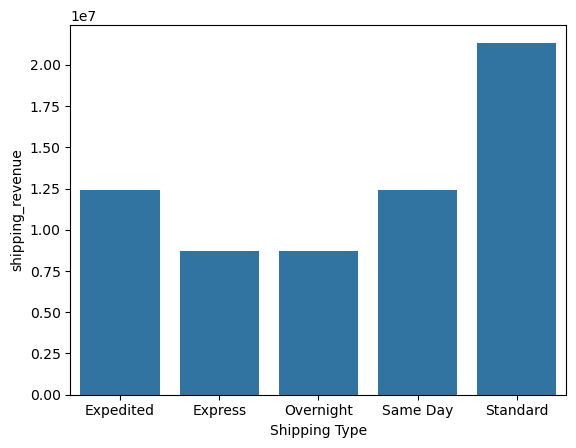

In [88]:
sns.barplot(
    data = metrics['revenue_by_shipping'],
    x = 'Shipping Type',
    y = 'shipping_revenue')

<Axes: xlabel='months', ylabel='Add-on Total'>

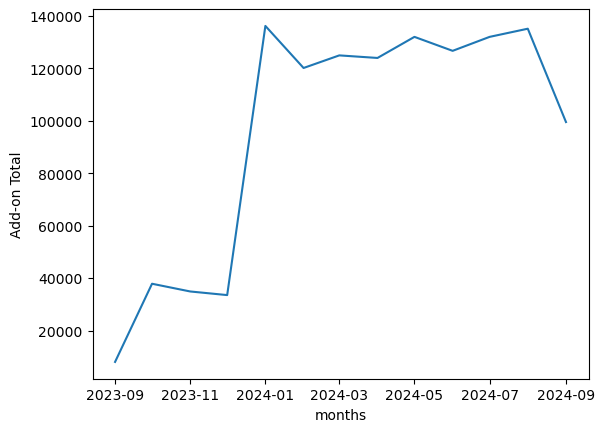

In [85]:
sns.lineplot(
    data=metrics['addons_by_months'], 
    x='months', 
    y='Add-on Total', 
    
)

<Axes: xlabel='cohort_index', ylabel='month'>

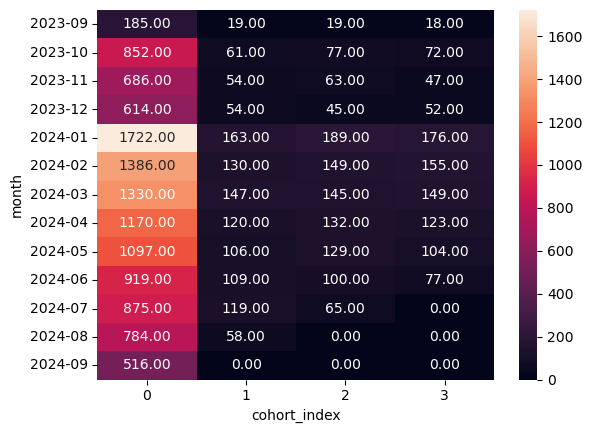

In [92]:
sns.heatmap(
    metrics['cohort'], 
    annot=True, 
    fmt=".2f", 
)